In [1]:
import sys
sys.path.insert(0, '../')

print(sys.path)

['../', '/opt/homebrew/Cellar/python@3.13/3.13.5/Frameworks/Python.framework/Versions/3.13/lib/python313.zip', '/opt/homebrew/Cellar/python@3.13/3.13.5/Frameworks/Python.framework/Versions/3.13/lib/python3.13', '/opt/homebrew/Cellar/python@3.13/3.13.5/Frameworks/Python.framework/Versions/3.13/lib/python3.13/lib-dynload', '', '/Users/margovsk/Desktop/source-code/obsidian/.venv/lib/python3.13/site-packages']


In [2]:
import obsidian
import pandas as pd
import numpy as np
print(f'obsidian version: ' + obsidian.__version__)

from obsidian.experiment import AdvExpDesigner
from obsidian.experiment.sampling import sample_with_bias, best_sample

/Users/margovsk/Desktop/source-code/obsidian/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


obsidian version: 0.8.6-test


In [3]:
#generate random data for this demo
np.random.seed(42)

n = 1000
demo_data = pd.DataFrame({
    'reagent_conc': np.round(np.random.uniform(0.1, 1.0, n), 2),
    'ionic_strength': np.round(np.random.uniform(10, 100, n), 2),
    'surfactant_conc': np.round(np.random.uniform(0.01, 0.2, n), 3),
    'compound_A': np.round(np.random.uniform(0, 50, n), 2),
    'compound_B': np.round(np.random.uniform(0, 50, n), 2),
    'sugar': np.random.choice(['glucose', 'fructose', 'sucrose'], n),
    'surfactant': np.random.choice(['SDS', 'Tween20', 'TritonX'], n),
    'buffer': np.random.choice(['PBS', 'Tris', 'HEPES'], n),
    'pH': np.round(np.random.uniform(5.5, 8.5, n), 2)
})

demo_data.index.name = 'FormulationID'
demo_data

,reagent_conc,ionic_strength,surfactant_conc,compound_A,compound_B,sugar,surfactant,buffer,pH
FormulationID,,,,,,,,,
0,0.44,26.66,0.060,33.64,28.60,sucrose,Tween20,Tris,7.11
1,0.96,58.77,0.057,39.83,40.27,sucrose,Tween20,PBS,8.30
2,0.76,88.57,0.182,12.52,38.01,sucrose,SDS,PBS,8.00
3,0.64,75.90,0.057,31.24,7.69,fructose,Tween20,Tris,8.03
4,0.24,82.59,0.062,28.59,7.46,sucrose,SDS,Tris,6.41
...,...,...,...,...,...,...,...,...,...
995,0.18,69.13,0.174,22.11,44.87,glucose,SDS,Tris,8.27
996,0.93,96.10,0.040,16.72,5.97,glucose,SDS,PBS,7.77
997,0.22,16.21,0.069,19.73,16.39,sucrose,SDS,HEPES,7.70


In [4]:
#Initialize existing experimental data as an AdvExpDesigner object
designer = AdvExpDesigner(design_df=demo_data)

Random seed for reproducibility: 220
Weights min: 0.000819672131147541 max: 0.002459016393442623


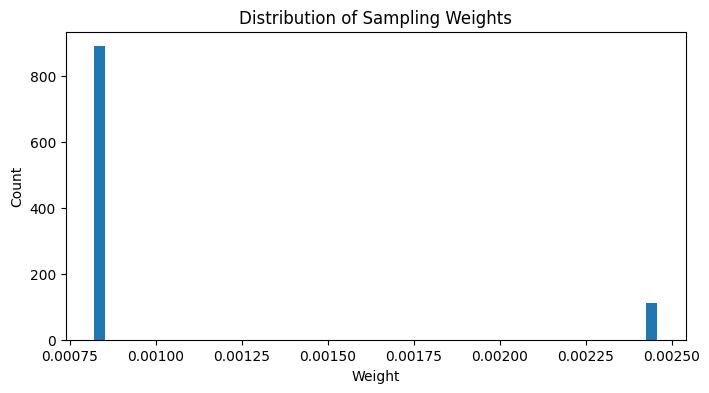

,reagent_conc,ionic_strength,surfactant_conc,compound_A,compound_B,sugar,surfactant,buffer,pH
FormulationID,,,,,,,,,
369,0.16,31.38,0.149,34.73,9.22,sucrose,Tween20,Tris,6.49
379,0.35,63.37,0.162,34.95,25.28,fructose,SDS,PBS,7.61
642,0.29,56.89,0.159,23.40,42.93,sucrose,TritonX,PBS,7.57
241,0.96,79.89,0.017,21.45,19.80,glucose,TritonX,HEPES,5.89
339,0.19,12.76,0.090,32.71,10.82,fructose,SDS,PBS,6.24
...,...,...,...,...,...,...,...,...,...
343,0.49,75.45,0.077,7.82,41.32,fructose,TritonX,Tris,5.70
634,0.20,93.45,0.145,4.69,6.87,fructose,TritonX,Tris,6.85
906,0.84,96.23,0.195,25.70,48.29,glucose,TritonX,HEPES,6.68


In [5]:
"""
You can sample an existing dataset with or without bias: 
Bias dictionary format : {"column": [lower_bound, upper_bound, relative_weight]}

- Weight >1 increases sampling probability for in-range rows.
- Weight <1 decreases it.
- Weight = 0 excludes those rows entirely.
"""

bias = {
    "ionic_strength": [50, 60, 3.0], 
}

seed = np.random.randint(0,1000)
print(f"Random seed for reproducibility: {seed}")

#We can easily create a random sample of n samples with weights using built in Pandas functions
#enforce = True allows you to force the boundary to be true ; resultant sample may not be space-filling.
sample = sample_with_bias(designer.design, n=1000, replace=False, seed=seed, bias=bias, plot_weights=True, enforce=False)

sample

In [6]:
#One-hot encode your categorical columns for easy handling in determining Euclidean distance
df_encoded = pd.get_dummies(designer.design, columns=["sugar", "surfactant", "buffer"], dtype=int) 

Random seed for reproducibility: 994
Weights min: 0.000819672131147541 max: 0.002459016393442623


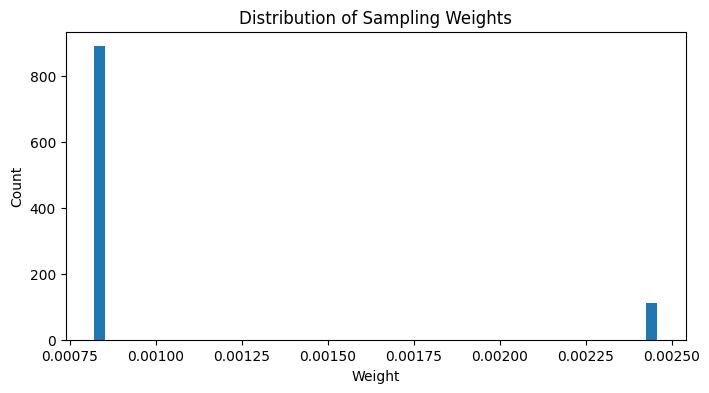

{'score': 4.498930450581275, 'metric': 'hybrid', 'n_trials': 1000}


,reagent_conc,ionic_strength,surfactant_conc,compound_A,compound_B,pH,sugar_fructose,sugar_glucose,sugar_sucrose,surfactant_SDS,surfactant_TritonX,surfactant_Tween20,buffer_HEPES,buffer_PBS,buffer_Tris
FormulationID,,,,,,,,,,,,,,,
326,0.60,26.39,0.166,40.15,1.10,6.39,1,0,0,1,0,0,1,0,0
251,0.45,53.34,0.183,5.77,3.10,5.64,0,0,1,0,1,0,1,0,0
81,0.66,18.05,0.022,44.15,11.67,7.53,0,1,0,0,1,0,1,0,0
83,0.16,89.12,0.183,29.38,37.35,5.89,1,0,0,1,0,0,0,1,0
687,0.35,53.84,0.089,19.37,0.54,8.11,0,1,0,1,0,0,0,0,1
603,0.18,41.95,0.070,13.93,18.51,7.10,0,0,1,0,0,1,0,1,0
963,0.45,44.54,0.196,29.16,37.43,6.64,0,0,1,0,1,0,0,0,1
756,0.66,96.36,0.099,9.23,0.50,6.13,0,1,0,0,1,0,0,1,0
534,0.79,47.22,0.150,11.63,27.76,7.96,0,0,1,1,0,0,1,0,0


In [7]:
"""
perform random sampling n_trial times, select the best one via criteria metric:
metric:
    - "maximin":   maximize the minimum pairwise Euclidean distance
    - "mean_nn":   maximize the mean nearest-neighbor Euclidean distance
    - "hybrid":    0.6*maximin + 0.4*mean_nn 
"""
seed = np.random.randint(0,1000)
print(f"Random seed for reproducibility: {seed}")

optimal_sample, info = best_sample(
    df_encoded, 10, feature_cols=df_encoded.columns, n_trials=1000,
    bias=bias, plot_weights=True, enforce=False, random_state=seed, metric="hybrid"
)

print(info)
optimal_sample


In [8]:
#decode from one-hot encoding
normal_cols = list(optimal_sample.columns)[0:6]
encoded_cols = list(optimal_sample.columns)[6:]
decoded = pd.from_dummies(optimal_sample[encoded_cols],sep="_")
optimal_design_decoded = pd.concat([optimal_sample[normal_cols], decoded], axis=1)
optimal_design_decoded

,reagent_conc,ionic_strength,surfactant_conc,compound_A,compound_B,pH,sugar,surfactant,buffer
FormulationID,,,,,,,,,
326,0.60,26.39,0.166,40.15,1.10,6.39,fructose,SDS,HEPES
251,0.45,53.34,0.183,5.77,3.10,5.64,sucrose,TritonX,HEPES
81,0.66,18.05,0.022,44.15,11.67,7.53,glucose,TritonX,HEPES
83,0.16,89.12,0.183,29.38,37.35,5.89,fructose,SDS,PBS
687,0.35,53.84,0.089,19.37,0.54,8.11,glucose,SDS,Tris
603,0.18,41.95,0.070,13.93,18.51,7.10,sucrose,Tween20,PBS
963,0.45,44.54,0.196,29.16,37.43,6.64,sucrose,TritonX,Tris
756,0.66,96.36,0.099,9.23,0.50,6.13,glucose,TritonX,PBS
534,0.79,47.22,0.150,11.63,27.76,7.96,sucrose,SDS,HEPES


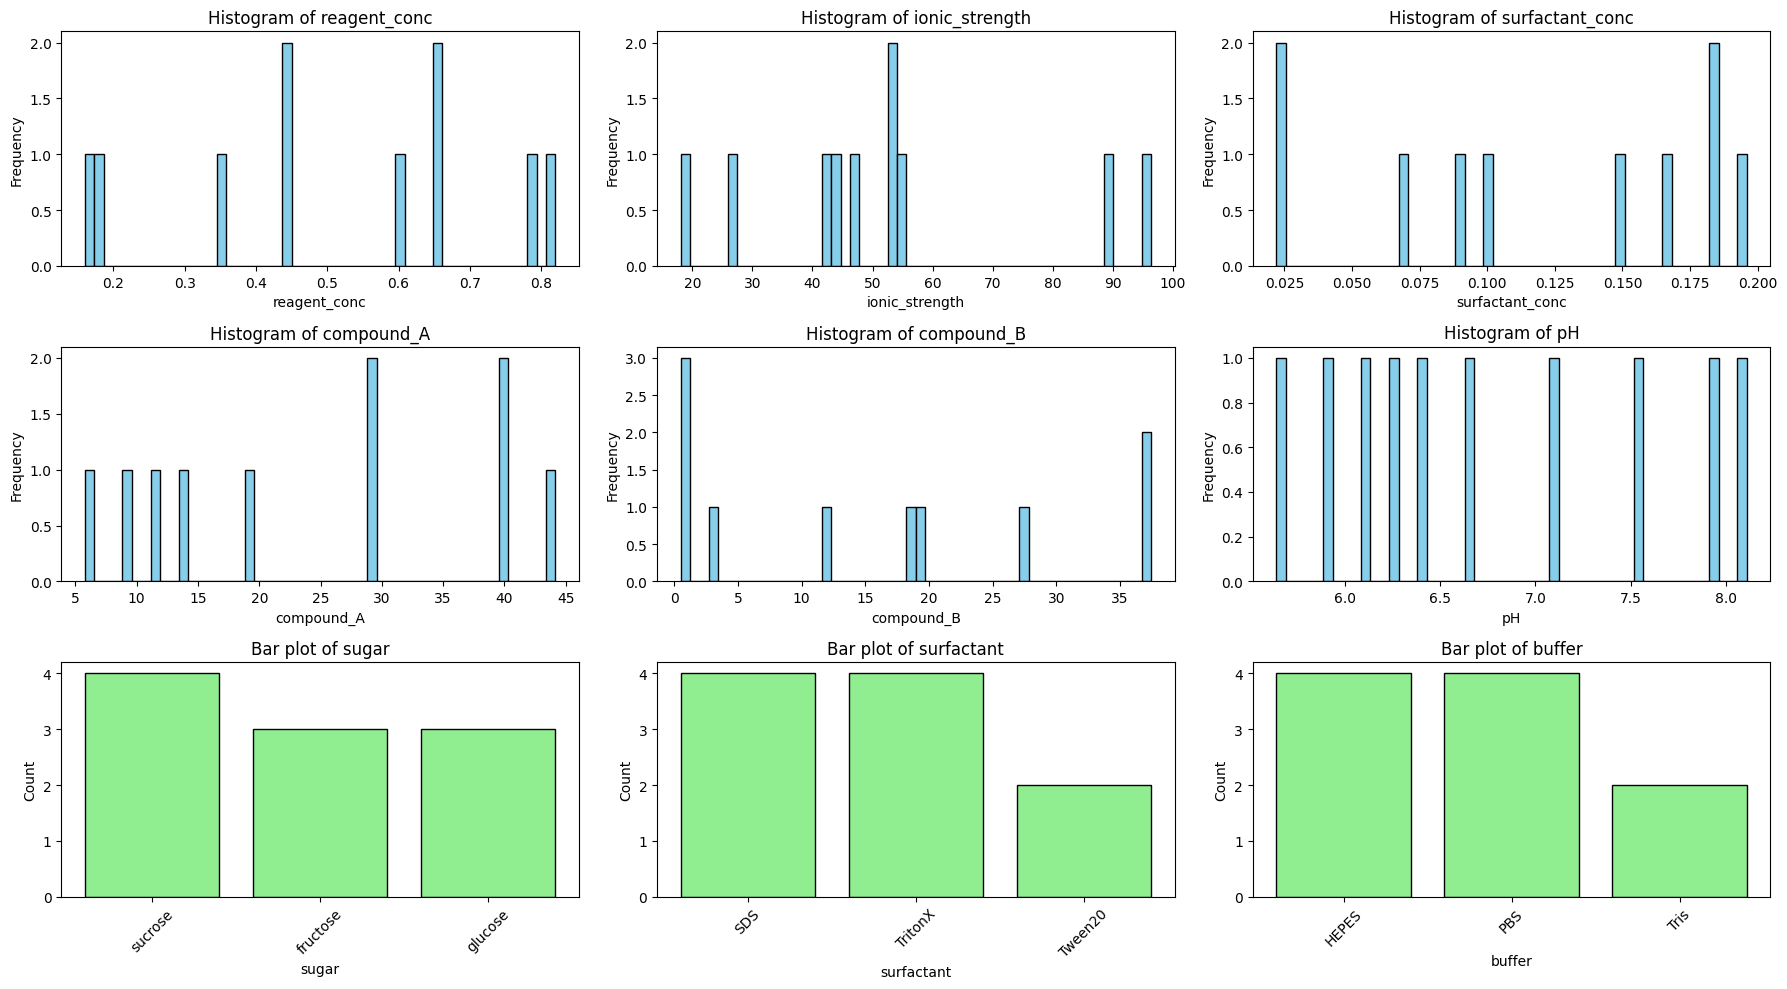

None


In [9]:
print(designer.plot_histograms(optimal_design_decoded))